# Esercizi Avanzati — Difficoltà Alta
Laboratorio di Programmazione 2


---
## Esercizio 1 — NumPy: Gestione Prezzi con Indicizzazione Avanzata

Un negozio vende **8 prodotti** con i seguenti prezzi (in euro):
`12.50, 8.99, 45.00, 3.75, 22.10, 67.80, 5.50, 30.00`

1. Crea un array NumPy `prezzi` con questi valori.

2. Applica uno **sconto del 15%** a tutti i prodotti che costano **più di 20 €**.

3. Arrotonda tutti i prezzi a **2 decimali** usando NumPy (non usare `round()` di Python).

4. Crea un secondo array `quantita` con i seguenti valori:
   `[10, 25, 3, 50, 8, 2, 40, 5]`  
   Calcola il **fatturato totale** (somma di `prezzi * quantita`).

5. Trova gli **indici** dei 3 prodotti con il **maggiore fatturato** (`prezzo * quantità`).  
   Stampa il prezzo e la quantità di questi 3 prodotti.

6. Normalizza l'array `prezzi` tra 0 e 1 (min-max normalization):  
   $$\hat{p}_i = \frac{p_i - p_{\min}}{p_{\max} - p_{\min}}$$  
   Verifica che il minimo sia 0.0 e il massimo sia 1.0.

7. Calcola la **media** e la **deviazione standard** dei prezzi originali.  
   Quanti prodotti hanno un prezzo **superiore di almeno 1 deviazione standard rispetto alla media**?

In [38]:
import numpy as np

prezzi = np.array([12.50, 8.99, 45.00, 3.75, 22.10, 67.80, 5.50, 30.00])

prezzi[prezzi > 20] = prezzi[prezzi > 20] - prezzi[prezzi > 20] * 15/100

prezzi = prezzi.round(2)

quantita = np.array([10, 25, 3, 50, 8, 2, 40, 5])

fatturato_tot = sum(prezzi*quantita)

fatturato = prezzi * quantita
prodotti = np.array([prezzi, quantita, fatturato])

idx_top3 = np.argsort(fatturato)[-3:] [::-1]    #-3 prende gli ultimi tre, -1 inverte mettendoli in ordine decrescente
for i in idx_top3:
    print(f"Prodotto {i}: prezzo: {prezzi[i]}, quantità = {quantita[i]}, fatturato = {fatturato[i]}")

p_min, p_max = prezzi.min(), prezzi.max()
prezzi_norm = (prezzi - p_min) / (p_max - p_min)

media = prezzi.mean()
stdeviation = prezzi.std()
prodotti_costosi = prezzi[prezzi > media + stdeviation]


Prodotto 1: prezzo: 8.99, quantità = 25, fatturato = 224.75
Prodotto 6: prezzo: 5.5, quantità = 40, fatturato = 220.0
Prodotto 3: prezzo: 3.75, quantità = 50, fatturato = 187.5


array([57.63])

---
## Esercizio 2 — Simulazione Monte Carlo: Stima di π

Il metodo Monte Carlo permette di stimare π generando punti casuali all'interno di un quadrato unitario e contando quanti cadono nel cerchio unitario inscritto.

$$\hat{\pi} = 4 \cdot \frac{\text{punti dentro il cerchio}}{\text{punti totali}}$$

1. Scrivi una funzione `stima_pi(N, seed=42)` che:
   - Genera `N` coppie di coordinate `(x, y)` uniformemente in `[-1, 1] × [-1, 1]`.
   - Conta quanti punti soddisfano `x² + y² ≤ 1`.
   - Restituisce la stima di π.

2. Chiama la funzione per `N = [100, 1000, 10000, 100000, 1000000]`.  
   Calcola l'**errore assoluto** rispetto a `np.pi` per ogni valore di N.

3. Plotta su scala **semilogaritmica (asse x in log)** l'errore assoluto in funzione di N.  
   Aggiungi una linea tratteggiata proporzionale a $1/\sqrt{N}$ (la convergenza teorica di Monte Carlo) per confronto.

4. Esegui la stima per `N = 10000` con **50 seed diversi** (da 0 a 49).  
   Calcola media e deviazione standard delle 50 stime.  
   Quante stime rientrano nell'intervallo $[\pi - 0.05,\ \pi + 0.05]$?

💡 *Usa esclusivamente operazioni vettoriali NumPy, senza cicli `for` nei punti 1–2.*

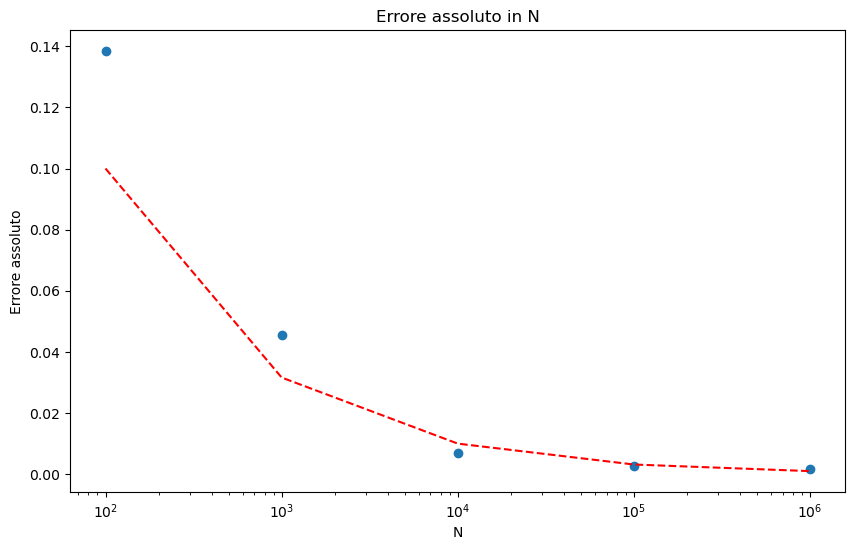

np.int64(50)

In [100]:
import numpy as np
import matplotlib.pyplot as plt

def stima_pi (N, seed = 42):

    np.random.seed(seed)
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)

    dist = x**2 + y**2

    inside = np.sum(dist <= 1)

    pi = 4 * (inside / N)

    return pi

N = np.array([100, 1000, 10000, 100000, 1000000])
absolute_err = np.array([abs(stima_pi(n) - np.pi) for n in N])
absolute_err

plt.figure(figsize = (10, 6))
plt.scatter(x = N, y = absolute_err)
plt.plot(N, 1/(N**(1/2)), color = "red", linestyle = "--")
plt.xscale("log")
plt.title("Errore assoluto in N")
plt.ylabel("Errore assoluto")
plt.xlabel("N")
plt.show()


newN = 10000
S = np.arange(50)

stime = np.array([stima_pi(newN, s) for s in S])

media_stime = stime.mean()
std_stime = stime.std()

np.sum((stime >= np.pi - 0.5) & (stime <= np.pi + 0.5))



---
## Esercizio 3 — NumPy: Indicizzazione Avanzata su Matrici

Imposta il seed con `np.random.seed(7)`.

1. Genera una matrice `M` di dimensioni **6 × 8** con valori interi casuali compresi tra **-20 e 20** (estremi inclusi).

2. Per ogni **colonna**, trova il **valore massimo** e la sua **posizione di riga**.  
   Restituisci due array: uno con i massimi, uno con gli indici di riga.

3. Sostituisci tutti i valori **negativi** della matrice con il loro **valore assoluto** (senza usare cicli).

4. Calcola la **norma L2** (norma euclidea) di ogni riga.  
   Normalizza ogni riga dividendola per la sua norma L2 (ottieni righe con norma = 1).  
   Verifica che la norma di ogni riga normalizzata sia 1.0 (a meno di errori floating point).

5. Seleziona la **sottomatrice** formata dalle righe con **indice pari** e dalle colonne con **indice dispari**.  
   Qual è la sua forma (`shape`)?

6. Usando la matrice originale (prima delle modifiche), costruisci un vettore 1D con tutti gli elementi
   che si trovano **sopra la diagonale principale** (esclusa la diagonale stessa).  
   *(Suggerimento: esplora `np.triu_indices`.)*

In [ ]:
import numpy as np

np.random.seed(7)
M = np.random.randint(-20, 21, size = (6, 8))
print(M)

max_values = M.max(axis = 0)
row_indexs = M.argmax(axis = 0)
print("Massimi per colonna: ", max_values)
print("Indici di riga: ", row_indexs)

M_abs =  np.abs(M)
print(M_abs)

rows = M_abs[::2]
sub = rows[:, 1::2]
print(sub)
print("Shape: ", sub.shape)


[[-16   5 -17  -1   3  19   8  -6]
 [  3 -12   5   6 -12  19  18 -16]
 [-13 -20  -9 -14  -1 -15   4 -20]
 [ 14 -11  -6  18 -16 -11   3  15]
 [-17 -12  -1 -19 -20  -4  11   9]
 [  8 -13   3 -10  15 -20 -13   3]]
Massimi per colonna:  [14  5  5 18 15 19 18 15]
Indici di riga:  [3 0 1 3 5 0 1 3]
[[16  5 17  1  3 19  8  6]
 [ 3 12  5  6 12 19 18 16]
 [13 20  9 14  1 15  4 20]
 [14 11  6 18 16 11  3 15]
 [17 12  1 19 20  4 11  9]
 [ 8 13  3 10 15 20 13  3]]
[[ 5  1 19  6]
 [20 14 15 20]
 [12 19  4  9]]
Shape:  (3, 4)


---
## Esercizio 4 — Pandas: Analisi Dataset `gapminder`

Carica il dataset `gapminder` con:
```python
import plotly.express as px
df = px.data.gapminder()
```
Il dataset contiene dati su popolazione, speranza di vita e PIL pro capite per vari Paesi nel tempo.

1. Visualizza le **prime 5 righe** e il **riepilogo statistico** (`describe`) del dataset.

2. Quanti **paesi unici** e quanti **anni unici** contiene il dataset?

3. Filtra solo i dati dell'anno **2007**.  
   Trova il **paese con la speranza di vita più alta** e quello con la **più bassa**.

4. Calcola, per ogni **continente** nell'anno 2007, la **speranza di vita media ponderata sulla popolazione**.  
   $$\bar{l}_c = \frac{\sum_i (\text{lifeExp}_i \cdot \text{pop}_i)}{\sum_i \text{pop}_i}$$  
   Ordina i continenti dal valore più alto al più basso.

5. Crea una nuova colonna `gdp_total` = `gdpPercap * pop` (PIL totale del paese).  
   Per ogni anno, trova il **paese con il PIL totale più alto**.

6. Analizza l'evoluzione della **speranza di vita dell'Italia** dal 1952 al 2007.  
   Di quanti anni è aumentata? Qual è il tasso di crescita medio annuo?

7. Crea un grafico a linee con la speranza di vita nel tempo per i seguenti 5 paesi:  
   `Italy, France, Germany, United States, Japan`.  
   Ogni paese deve avere una linea di colore diverso con legenda.

8. Crea un **scatter plot** per l'anno 2007 con:
   - asse x: `gdpPercap` (scala logaritmica)
   - asse y: `lifeExp`
   - dimensione dei punti proporzionale alla popolazione
   - colore dei punti per continente

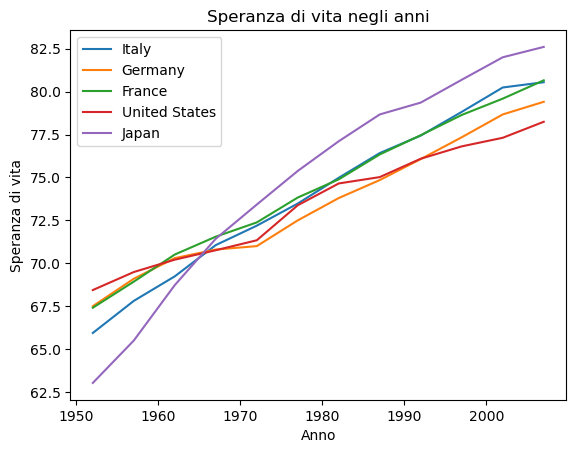

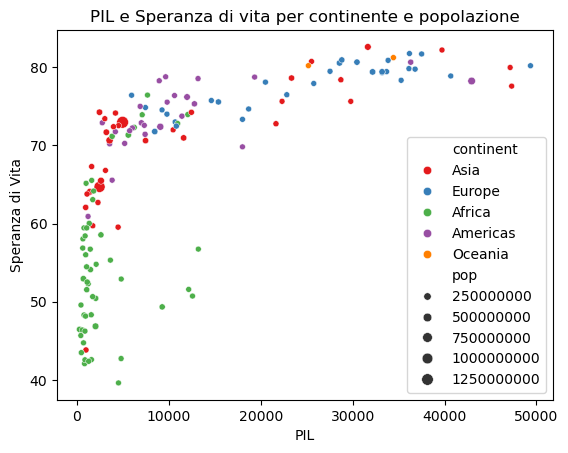

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

df = px.data.gapminder()
df.head(5)
df.describe()
df["year"].value_counts()
df["country"].value_counts()
# #esistono 12 anni diversi e 142 paesi diversi

df[df["year"] == 2007]["lifeExp"].max()
df[df["year"] == 2007]["lifeExp"].min()

media_ponderata = (df[df["year"] == 2007]["lifeExp"] * df["pop"]).sum() / df["pop"].sum()

df["gdp_total"] = df["gdpPercap"] * df["pop"]
df.loc[df.groupby("year")["gdp_total"].idxmax(), ["year", "country", "gdp_total"]]

italia = df[df["country"] == "Italy"]
increase = italia["lifeExp"].iloc[-1] - italia["lifeExp"].iloc[0]
years = italia["year"].iloc[-1] - italia["year"].iloc[0]
increase / years

countries = ["Italy", "Germany", "France", "United States", "Japan"]

for c in countries:

    country = df[df["country"] == c]
    plt.plot(country["year"], country["lifeExp"], label = c)    #label serve per la legenda

plt.legend()
plt.title("Speranza di vita negli anni")
plt.xlabel("Anno")
plt.ylabel("Speranza di vita")
plt.show()


y2007 = df[df["year"] == 2007]

sns.scatterplot(
    data = y2007,
    x = "gdpPercap",
    y = "lifeExp",
    size = "pop",
    hue = "continent",
    palette = "Set1")
plt.title("PIL e Speranza di vita per continente e popolazione")
plt.ylabel("Speranza di Vita")
plt.xlabel("PIL")
plt.show()

---
## Esercizio 5 — Pulizia Dati e Feature Engineering

Carica il dataset `titanic` dal seguente URL:  
`url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"`

1. Controlla i **valori mancanti** per ogni colonna. Quali colonne hanno più del **20% di valori mancanti**?

2. Gestisci i valori mancanti:
   - `Age`: riempi con la **mediana per classe (`Pclass`) e sesso (`Sex`)**.
   - `Embarked`: riempi con la **moda**.
   - Elimina la colonna `Cabin` (troppi valori mancanti).

3. Crea le seguenti **nuove colonne**:
   - `FamilySize` = `SibSp + Parch + 1` (incluso il passeggero stesso)
   - `IsAlone` = 1 se `FamilySize == 1`, altrimenti 0
   - `AgeGroup`: categorizza `Age` in `'Child'` (< 16), `'Adult'` (16–60), `'Senior'` (> 60)

4. Calcola il **tasso di sopravvivenza** (`Survived`) per:
   - Ogni `Pclass`
   - Ogni `Sex`
   - Ogni `AgeGroup`
   - La combinazione `Pclass` + `Sex` (usa `groupby` con più colonne)

5. Crea un grafico a barre orizzontale con il tasso di sopravvivenza per la combinazione `Pclass` + `Sex`.

6. Trova i **5 cognomi più comuni** tra i passeggeri.  
   *(Suggerimento: il cognome è la prima parola della colonna `Name`, prima della virgola.)*

7. I passeggeri `IsAlone` avevano un tasso di sopravvivenza significativamente diverso da chi viaggiava in famiglia?  
   Mostra i dati a supporto della tua risposta.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

titanic = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
(titanic.isna().sum()/titanic.count())*100

titanic["Age"].fillna(titanic["Age"].median())
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])
titanic.drop(columns = ["Cabin"], inplace = True)   #elimina una colonnna

titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = titanic["FamilySize"]
titanic.loc[titanic["IsAlone"] != 1, "IsAlone"] = 0 #per fare tutto in una riga
titanic["AgeGroup"] = 


0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: IsAlone, Length: 891, dtype: int64

---
## Esercizio 6 — Curve Fitting: Modello Non Lineare

Imposta il seed con `np.random.seed(42)`, poi genera i dati:

```python
x = np.linspace(0, 4 * np.pi, 200)
y = 2.5 * np.sin(1.3 * x + 0.5) * np.exp(-0.1 * x) + np.random.normal(0, 0.3, 200)
```

I dati seguono un'**oscillazione sinusoidale con decadimento esponenziale** (sinusoide smorzata).

1. Scrivi una funzione `modello(x, A, omega, phi, gamma)` che implementa:  
   $$f(x) = A \cdot \sin(\omega x + \phi) \cdot e^{-\gamma x}$$

2. Usa `scipy.optimize.curve_fit` per trovare i parametri ottimali `A, ω, φ, γ`.  
   Fornisci dei **valori iniziali ragionevoli** (`p0`) — justifica la tua scelta.

3. Stampa i parametri trovati e confrontali con quelli veri: `A=2.5, ω=1.3, φ=0.5, γ=0.1`.

4. Calcola il **residuo** per ogni punto: $r_i = y_i - f(x_i)$.  
   Calcola:
   - RMSE (Root Mean Square Error): $\sqrt{\frac{1}{N}\sum r_i^2}$
   - MAE (Mean Absolute Error): $\frac{1}{N}\sum |r_i|$

5. Crea una figura con **2 subplot**:
   - Subplot 1: dati originali (scatter) + curva fittata (linea rossa) + curva teorica (linea verde tratteggiata).
   - Subplot 2: residui in funzione di x (scatter) + linea orizzontale a y=0.

6. **Sfida**: prova a fittare un **modello sbagliato** — solo `A * sin(ω * x + φ)` (senza decadimento).  
   Confronta i residui dei due fit. Qual è peggiore? Perché?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

def modello(x, A, omega, phi, gamma):
    return A*np.sin(omega*x + phi)*np.exp(-gamma*x)

np.random.seed(42)
x = np.linspace(0, 4 * np.pi, 200)
y = 2.5 * np.sin(1.3 * x + 0.5) * np.exp(-0.1 * x) + np.random.normal(0, 0.3, 200)

curva, _ = sp.optimize.curve_fit(modello, x, y)
curva

residuals = []
for item in curva:
    residuals.append()

array([2.40321962, 1.28959491, 0.57747849, 0.09095623])